imu.csv file generated successfully!

Feature Engineering Completed!

Model Training Completed!

========== METRICS TABLE ==========
      Metric  Value
0  Precision    1.0
1     Recall    1.0
2   F1 Score    1.0

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       391
         1.0       1.00      1.00      1.00         9

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400


========== CONFUSION MATRIX ==========
[[391   0]
 [  0   9]]


<Figure size 600x500 with 0 Axes>

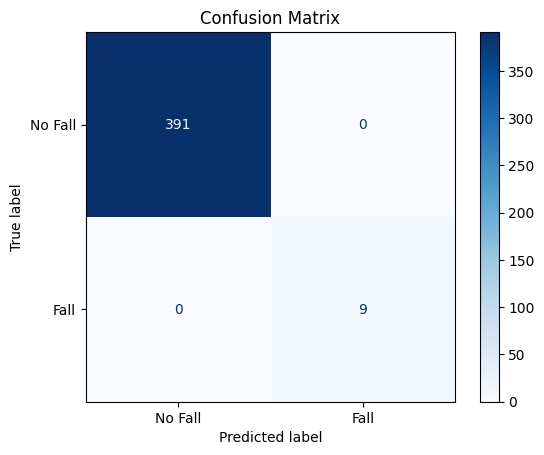

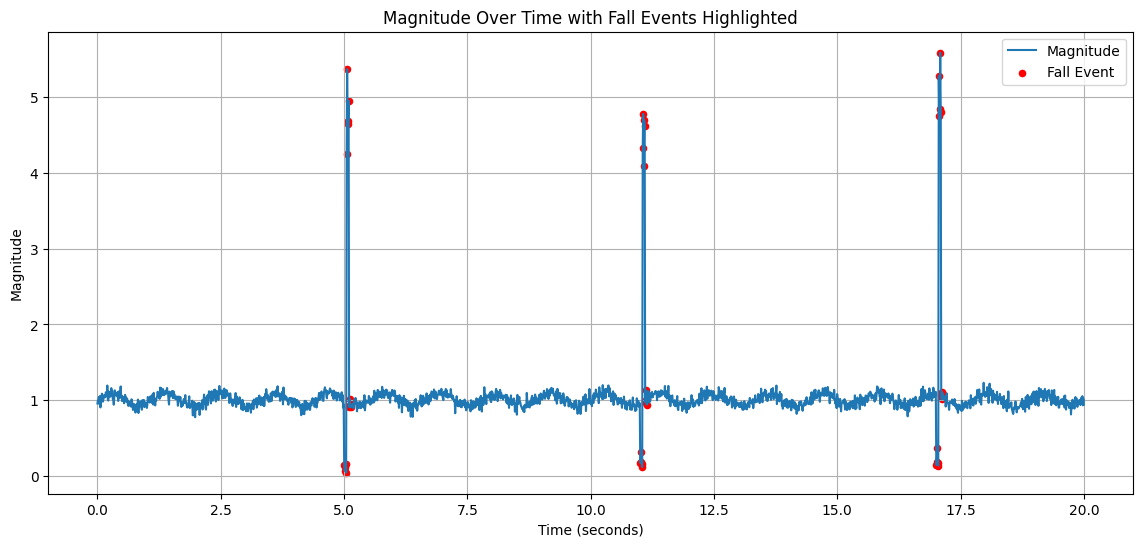

In [ ]:
# =========================================
# TASK 4 - FALL DETECTION FROM SENSOR DATA
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ====================================================
# STEP 1: GENERATE SENSOR DATA AND SAVE CSV
# ====================================================

np.random.seed(42)

t = np.linspace(0, 20, 2000)

ax = 0.1 * np.sin(2 * np.pi * 1.8 * t) + np.random.normal(0, 0.05, 2000)
ay = 0.12 * np.sin(2 * np.pi * 1.8 * t) + np.random.normal(0, 0.05, 2000)
az = 1.0 + 0.08 * np.sin(2 * np.pi * 0.9 * t) + np.random.normal(0, 0.05, 2000)

label = np.zeros(2000)

# Add fall events
for ft in [5.0, 11.0, 17.0]:
    i = int(ft * 100)

    ax[i:i+5] = np.random.normal(0.05, 0.1, 5)
    az[i:i+5] = np.random.normal(0.05, 0.1, 5)

    ax[i+5:i+10] = np.random.normal(2.5, 0.3, 5)
    az[i+5:i+10] = np.random.normal(3.8, 0.4, 5)

    label[i:i+15] = 1

# Create dataframe
df = pd.DataFrame({
    't': t,
    'ax': ax,
    'ay': ay,
    'az': az,
    'fall': label
})

# Save CSV
df.to_csv('imu.csv', index=False)

print("imu.csv file generated successfully!")

# ====================================================
# STEP 2: FEATURE ENGINEERING
# ====================================================

# Magnitude
df['magnitude'] = np.sqrt(
    df['ax']**2 +
    df['ay']**2 +
    df['az']**2
)

# Rolling mean (window=10)
df['rolling_mean'] = (
    df['magnitude']
    .rolling(window=10)
    .mean()
)

# Rolling std (window=10)
df['rolling_std'] = (
    df['magnitude']
    .rolling(window=10)
    .std()
)

# Fill NaN values
df.fillna(0, inplace=True)

print("\nFeature Engineering Completed!")

# ====================================================
# STEP 3: PREPARE DATA
# ====================================================

features = [
    'ax',
    'ay',
    'az',
    'magnitude',
    'rolling_mean',
    'rolling_std'
]

X = df[features]
y = df['fall']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ====================================================
# STEP 4: TRAIN RANDOM FOREST MODEL
# ====================================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Completed!")

# ====================================================
# STEP 5: PREDICTIONS
# ====================================================

y_pred = model.predict(X_test)

# Metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# ====================================================
# STEP 6: METRICS TABLE
# ====================================================

metrics_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1 Score'],
    'Value': [precision, recall, f1]
})

print("\n========== METRICS TABLE ==========")
print(metrics_df)

print("\n========== CLASSIFICATION REPORT ==========")
print(classification_report(y_test, y_pred))

print("\n========== CONFUSION MATRIX ==========")
print(cm)

# ====================================================
# STEP 7: PLOT CONFUSION MATRIX
# ====================================================

plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Fall', 'Fall']
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

# ====================================================
# STEP 8: MAGNITUDE PLOT WITH FALL EVENTS
# ====================================================

plt.figure(figsize=(14, 6))

# Plot magnitude
plt.plot(
    df['t'],
    df['magnitude'],
    label='Magnitude'
)

# Highlight fall events in red
fall_data = df[df['fall'] == 1]

plt.scatter(
    fall_data['t'],
    fall_data['magnitude'],
    color='red',
    label='Fall Event',
    s=20
)

plt.xlabel("Time (seconds)")
plt.ylabel("Magnitude")
plt.title("Magnitude Over Time with Fall Events Highlighted")
plt.legend()
plt.grid(True)

plt.show()

# ====================================================
# STEP 9: WRITTEN ANSWER
# ====================================================


In [ ]:
display(metrics_df)

,Metric,Value
0,Precision,1.0
1,Recall,1.0
2,F1 Score,1.0
